In [1]:
import numpy as np
import torch
from torch.autograd import grad
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np

# from pinnutils import *
from scipy.interpolate import griddata
from itertools import product, combinations
from scipy.io import savemat, loadmat
from torch.optim.lr_scheduler import ExponentialLR, MultiStepLR
from tqdm import tqdm_notebook as tqdm 
import torch.nn as nn
import torch.nn.functional as F
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from tqdm import tqdm_notebook as tqdm
from scipy.linalg import sqrtm
from chebyshev_utils import *

import matplotlib as mpl
import matplotlib.font_manager
fpaths = matplotlib.font_manager.findSystemFonts()
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })
import seaborn as sns


/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'n

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
Ndim = 2; nsamples = 250;
nsnaps = 5; tp = np.linspace(0,4,nsnaps)
temp = np.random.normal(0,1,(nsnaps,nsamples,2))


Dist = np.zeros((nsnaps,nsamples,Ndim+1))
Dist[:,:,0:Ndim] = temp + 0;
for k in range(0, nsnaps):
    Dist[k,:,Ndim] = tp[k]


In [4]:
Dist[:,10,Ndim]

array([0., 1., 2., 3., 4.])

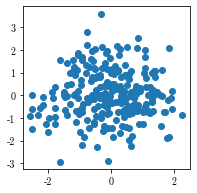

In [5]:
plt.scatter(Dist[2,:,0],Dist[2,:,1])
plt.gcf().set_size_inches(3,3)

In [6]:
before_ot = torch.tensor(Dist[:,:,0:Ndim],dtype=torch.float32)
batch_ot_samples = stitch_ot_trajectories(before_ot).to(device) #before_ot.to(device) #before_ot.to(device)

In [65]:
uniform_kind = torch.tensor(np.linspace(tp[0],tp[-1],1*tp.shape[0]))
first_kind = generate_firstkind_nodes(tp[0],tp[-1],1*tp.shape[0]);
second_kind, weights = generate_secondkind_nodes(tp[0],tp[-1],1*tp.shape[0]);

print(" data nodes ", tp)
print(" nodes of first kind ", first_kind)
print(" nodes of second kind ", second_kind)

data_nodes = torch.tensor(tp,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
uniform_nodes = torch.tensor(uniform_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
first_kind_nodes = torch.tensor(first_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
second_kind_nodes = torch.tensor(second_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)

batch_ot_samples_uniform = interpolate_old2new(batch_ot_samples, data_nodes, uniform_nodes).to(device);
batch_ot_samples_linear = interpolate_old2new(batch_ot_samples, data_nodes, second_kind_nodes).to(device);
batch_ot_samples_firstkind = interpolate_old2new_chebyshev(batch_ot_samples, data_nodes, first_kind_nodes, reg_=0.).to(device);
batch_ot_samples_secondkind = interpolate_old2new_chebyshev(batch_ot_samples, data_nodes, second_kind_nodes, reg_=0.).to(device);

batch_size = 100;
first_kind_batch = first_kind.expand(batch_size,-1).to(device);
second_kind_batch = second_kind.expand(batch_size,-1).to(device);
uniform_batch = uniform_kind.expand(batch_size,-1).to(device)

print(" shape of nodes ", first_kind_batch.shape, second_kind_batch.shape, uniform_batch.shape)

 data nodes  [0. 1. 2. 3. 4.]
 nodes of first kind  tensor([0.0979, 0.8244, 2.0000, 3.1756, 3.9021])
 nodes of second kind  tensor([0.0000, 0.5858, 2.0000, 3.4142, 4.0000])
 shape of nodes  torch.Size([100, 5]) torch.Size([100, 5]) torch.Size([100, 5])


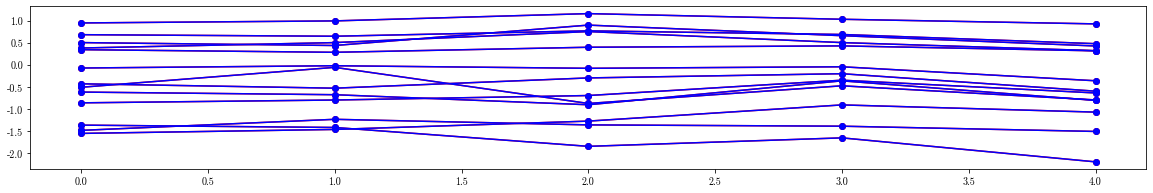

In [66]:
plt.plot(tp, batch_ot_samples[:,::20,1].cpu().data.numpy(),'-o',color='red')
#plt.plot(tp, Dist[:,::20,1],'-o',color='red')
plt.plot(uniform_nodes[0,:].cpu().data.numpy(), batch_ot_samples_uniform[:,::20,1].cpu().data.numpy(),'-o',color='blue')
plt.gcf().set_size_inches(20,3)

In [67]:
mass_vec = np.ones((nsnaps,))
for k in range(1,nsnaps):
    if(k<5):
        mass_vec[k] = 2*mass_vec[k-1]
    else:
        mass_vec[k] = mass_vec[k-1]/2

mass_vec = torch.tensor(mass_vec,dtype=torch.float32,device=device)
print(" mass_vec shape ", mass_vec)

 mass_vec shape  tensor([ 1.,  2.,  4.,  8., 16.], device='cuda:0')


In [68]:
time_data = torch.tensor(Dist[:,:,:],dtype=torch.float32,device=device) + 0;
#time_data = time_data[:,:,np.newaxis]
time_data[:,:,0:Ndim] = batch_ot_samples + 0;
#time_data[:,90,Ndim]
print(time_data.shape)
print(time_data[:,10,:])

torch.Size([5, 250, 3])
tensor([[-0.6888,  0.7382,  0.0000],
        [-0.8800,  0.7408,  1.0000],
        [-1.0794,  1.1054,  2.0000],
        [-1.0615,  0.9157,  3.0000],
        [-0.9964,  0.8747,  4.0000]], device='cuda:0')


In [69]:
nsamples

250

In [70]:
seed_ = 0; fac = 1; lam = 1e-4; lx = 1;
growth_net = DNN(sizes=[3,25,25,25,25,1],seed=seed_, activation=nn.ELU()).to(device)
print("#parameters:", sum(p.numel() for p in growth_net.parameters() if p.requires_grad))
params_FM = [{'params': growth_net.parameters(), 'lr': 1e-3}]
optimizer_FM = torch.optim.Adam(params_FM)
criterion = nn.MSELoss()
milestones_FM = [[1_000,1500,8_000,15000]]
scheduler_FM = MultiStepLR(optimizer_FM, milestones_FM[0], gamma=0.1)

start_time = time.time();
n_epochs = 20_01; dt = 1.0
for epoch in range(n_epochs):
    optimizer_FM.zero_grad()

    growth_ = growth_net(time_data).squeeze(-1)  # shape: (nsnaps, B)
    #Accumulate log-mass (integral) for each trajectory
    log_mass = np.log((1./nsamples))*torch.ones_like(growth_)  # (nsnaps, B)
    for k in range(1, nsnaps):
        log_mass[k] = log_mass[k-1] + 0.5 * dt * (growth_[k] + growth_[k-1])  # Trapezoidal rule
    # Convert to mass: m(x(t_k)) = exp(integral)
    mass_ = torch.exp(log_mass)
    # print(mass_.shape)

    pred_mass = torch.sum(mass_,axis=1)
    # #print(pred_mass)
    
    total_loss = torch.mean(((pred_mass - mass_vec)**2).flatten()) + 0.01*torch.mean(growth_.flatten()**2)
    total_loss.backward()
    optimizer_FM.step()
    scheduler_FM.step()
    
    if(epoch%200==0):
        print("epoch {}/{}, loss={:.10f},lr={:,.5f}\t\t\t".format(epoch+1, n_epochs, total_loss.item(), optimizer_FM.param_groups[0]['lr']), end="\r")  
        # print(" epoch ", epoch, " inferred beta ", inf_beta)
        print(optimizer_FM.param_groups[0]['lr'])

#parameters: 2076
0.001 1/2001, loss=3.3167719841,lr=0.00100			
0.001 201/2001, loss=0.0316317976,lr=0.00100			
0.001 401/2001, loss=0.0203638375,lr=0.00100			
0.001 601/2001, loss=0.0190167427,lr=0.00100			
0.001 801/2001, loss=0.0088895373,lr=0.00100			
0.00011001/2001, loss=0.0066853794,lr=0.00010			
0.00011201/2001, loss=0.0065286309,lr=0.00010			
0.00011401/2001, loss=0.0063717123,lr=0.00010			
1e-05 1601/2001, loss=0.0062835854,lr=0.00001			
1e-05 1801/2001, loss=0.0062657688,lr=0.00001			
1e-05 2001/2001, loss=0.0062459456,lr=0.00001			


In [71]:
growth_net.eval()
growth_ = growth_net(time_data).squeeze(-1)  # shape: (nsnaps, B)
    #Accumulate log-mass (integral) for each trajectory
log_mass = np.log(0.005)*torch.ones_like(growth_)  # (nsnaps, B)
for k in range(1, nsnaps):
    log_mass[k] = log_mass[k-1] + 0.5 * dt * (growth_[k] + growth_[k-1])  # Trapezoidal rule
    # Convert to mass: m(x(t_k)) = exp(integral)
mass_ = torch.exp(log_mass)
print(torch.sum(mass_,axis=1))

tensor([ 1.2500,  2.3541,  4.9996, 10.0249, 19.9938], device='cuda:0',
       grad_fn=<SumBackward1>)


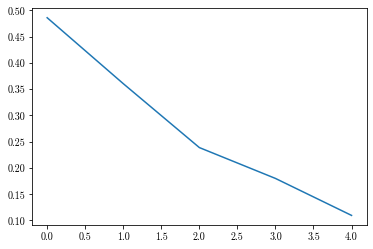

In [72]:
plt.plot(torch.mean(growth_[:,:],axis=1).cpu().data.numpy())

In [73]:
torch.mean(growth_[:,:],axis=1).cpu().data.numpy()

array([0.48601112, 0.36048877, 0.23877609, 0.18002197, 0.10961735],
      dtype=float32)

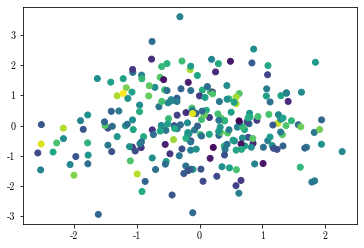

In [74]:
tind= 2;
plt.scatter(Dist[tind,:,0],Dist[tind,:,1],c=growth_[tind,:].cpu().data.numpy())

In [75]:
growth_net.eval()
growth_ = growth_net(time_data).squeeze()
mass_ = torch.ones_like(growth_).to(device)
for k in range(1, nsnaps):
    integral = 0;
    for j in range(0, k):
        integral = integral + growth_[k-1,:]*0.5 # dt = 0.5
    mass_[k,:] = torch.exp(integral)    

print(torch.sum(mass_,axis=1))

tensor([250.0000, 339.1864, 430.4131, 440.9484, 471.6649], device='cuda:0',
       grad_fn=<SumBackward1>)


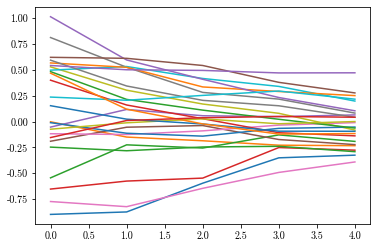

In [76]:
for k in range(0,nsamples,10):
    plt.plot(tp,growth_[:,k].cpu().data.numpy())